In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

In [2]:
# Dark chart style — looks professional in reports
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor']   = '#1a1d27'
plt.rcParams['axes.edgecolor']   = '#3a3d4d'
plt.rcParams['text.color']       = '#e0e0e0'
plt.rcParams['axes.labelcolor']  = '#e0e0e0'
plt.rcParams['xtick.color']      = '#9e9e9e'
plt.rcParams['ytick.color']      = '#9e9e9e'
plt.rcParams['grid.color']       = '#2a2d3a'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.5

C_BLUE   = '#6366f1'
C_GREEN  = '#10b981'
C_AMBER  = '#f59e0b'
C_RED    = '#ef4444'

In [3]:
#loading data
df_txn = pd.read_csv(r"C:\Users\HP\Downloads\edunet-IBM AIML project\retail_cleaned.csv", parse_dates=['date','invoicedate'])
df = pd.read_csv(r"C:\Users\HP\Downloads\edunet-IBM AIML project\retail_raw_data.csv", parse_dates=['date'])

print(f'Transactions : {len(df_txn):,} rows')
print(f'Daily data : {len(df):,} rows')


Transactions : 1,037,169 rows
Daily data : 22,420 rows


In [4]:
print('\n' + '='*55)
print('KEY BUSINESS METRICS')
print('='*55)


KEY BUSINESS METRICS


In [5]:
total_revenue = df_txn['revenue'].sum()
total_units = df_txn['quantity'].sum()
total_orders = df_txn['invoice'].nunique()
avg_order_value = total_revenue / total_orders
n_products = df_txn['stockcode'].nunique()
n_customers = df_txn['customer_id'].nunique()
n_countries = df_txn['country'].nunique()

In [6]:
print(f'Total Revenue     : £{total_revenue:>14,.2f}')
print(f'Units Sold        : {total_units:>14,}')
print(f'Total Invoices    : {total_orders:>14,}')
print(f'Avg Order Value   : £{avg_order_value:>14,.2f}')
print(f'Unique Products   : {n_products:>14,}')
print(f'Unique Customers  : {n_customers:>14,}')
print(f'Countries Served  : {n_countries:>14}')

Total Revenue     : £ 20,156,335.52
Units Sold        :     11,402,863
Total Invoices    :         39,601
Avg Order Value   : £        508.99
Unique Products   :          4,908
Unique Customers  :          5,861
Countries Served  :             43


## Monthly Revenue Trend

This is the MOST important chart in retail analysis.
It shows seasonality — critical for forecasting

In [7]:
monthly = (
    df_txn.groupby(df_txn['date'].dt.to_period('M'))
    .agg(revenue=('revenue','sum'), orders=('invoice','nunique'))
    .reset_index()
)
monthly['date'] = monthly['date'].dt.to_timestamp()

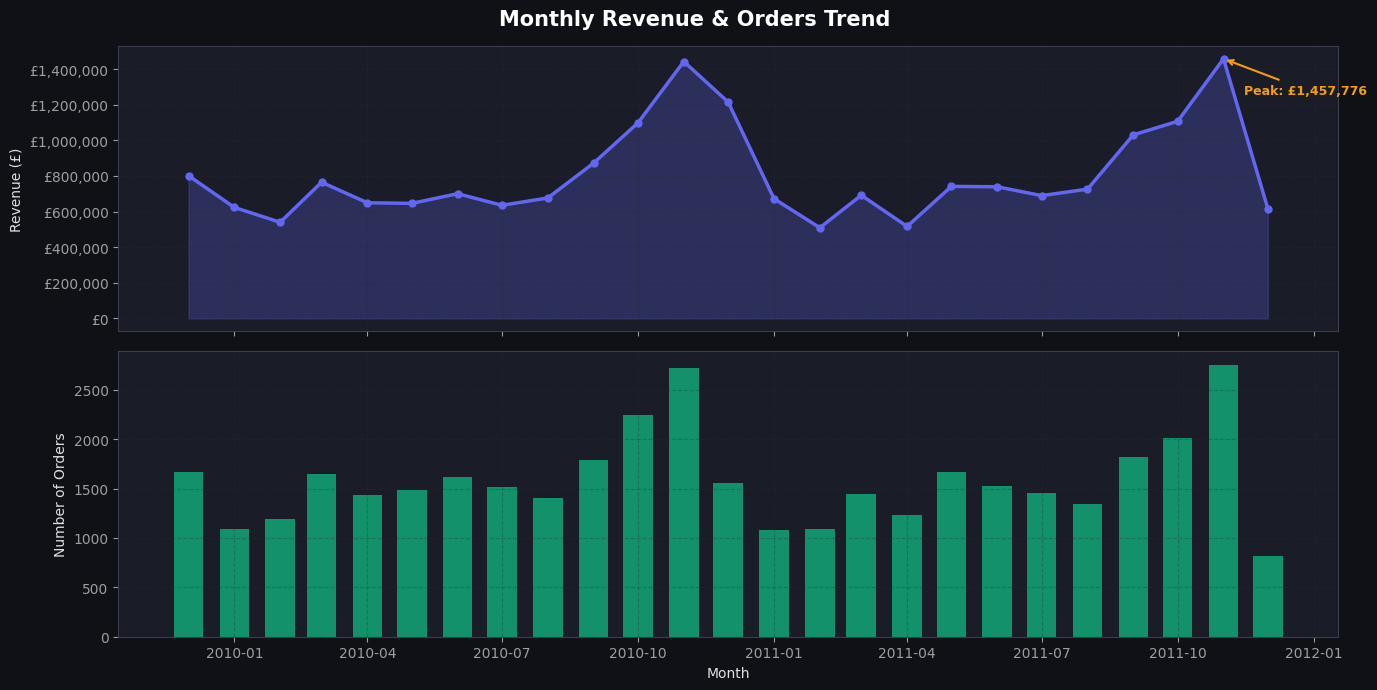

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Monthly Revenue & Orders Trend', fontsize=15,
             fontweight='bold', color='white')

ax1.fill_between(monthly['date'], monthly['revenue'], alpha=0.25, color=C_BLUE)
ax1.plot(monthly['date'], monthly['revenue'],
         color=C_BLUE, linewidth=2.5, marker='o', markersize=5)
ax1.set_ylabel('Revenue (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
ax1.grid(True, alpha=0.3)

# Annotate the peak month
peak = monthly.loc[monthly['revenue'].idxmax()]
ax1.annotate(f'Peak: £{peak["revenue"]:,.0f}',
    xy=(peak['date'], peak['revenue']),
    xytext=(15, -25), textcoords='offset points',
    color=C_AMBER, fontsize=9, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=C_AMBER, lw=1.5))

ax2.bar(monthly['date'], monthly['orders'],
        color=C_GREEN, alpha=0.75, width=20)
ax2.set_ylabel('Number of Orders')
ax2.set_xlabel('Month')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/HP/Downloads/edunet-IBM AIML project/chart_01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('Saved: chart_01_monthly_trend.png')
print('Insight: Strong Q4 seasonality — November is peak every year')

Saved: chart_01_monthly_trend.png
Insight: Strong Q4 seasonality — November is peak every year


## Seasonality & Weekly Patterns

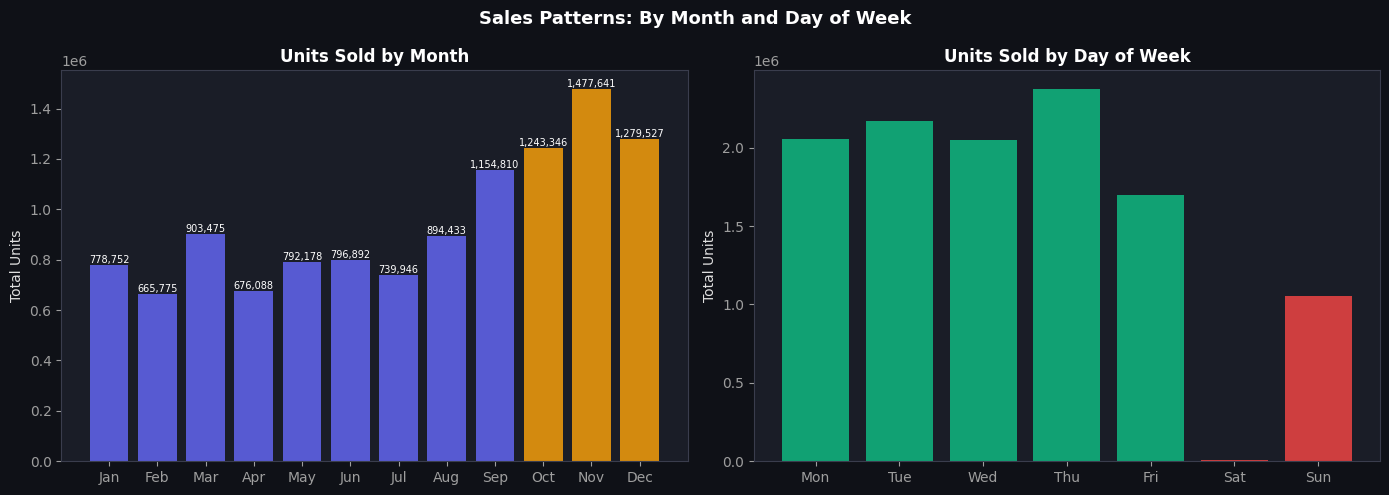

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales Patterns: By Month and Day of Week',
             fontsize=13, fontweight='bold', color='white')

# By month
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_qty = df_txn.groupby('month')['quantity'].sum()
col_m = [C_AMBER if m in [10,11,12] else C_BLUE for m in range(1,13)]
ax1.bar(month_names, monthly_qty.values, color=col_m, alpha=0.85)
ax1.set_title('Units Sold by Month', fontweight='bold', color='white')
ax1.set_ylabel('Total Units')
for i, v in enumerate(monthly_qty.values):
    ax1.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=7, color='white')

# By day of week
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_qty   = df_txn.groupby('day_of_week')['quantity'].sum()
col_d = [C_GREEN if d < 5 else C_RED for d in range(7)]
ax2.bar(dow_names, dow_qty.values, color=col_d, alpha=0.85)
ax2.set_title('Units Sold by Day of Week', fontweight='bold', color='white')
ax2.set_ylabel('Total Units')

plt.tight_layout()
plt.savefig('C:/Users/HP/Downloads/edunet-IBM AIML project/chart_02_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print('Saved: chart_02_seasonality.png')
print('Insight: Thursdays and Tuesdays peak — typical B2B ordering cycle')

Saved: chart_02_seasonality.png
Insight: Thursdays and Tuesdays peak — typical B2B ordering cycle


## Top Products & Countries

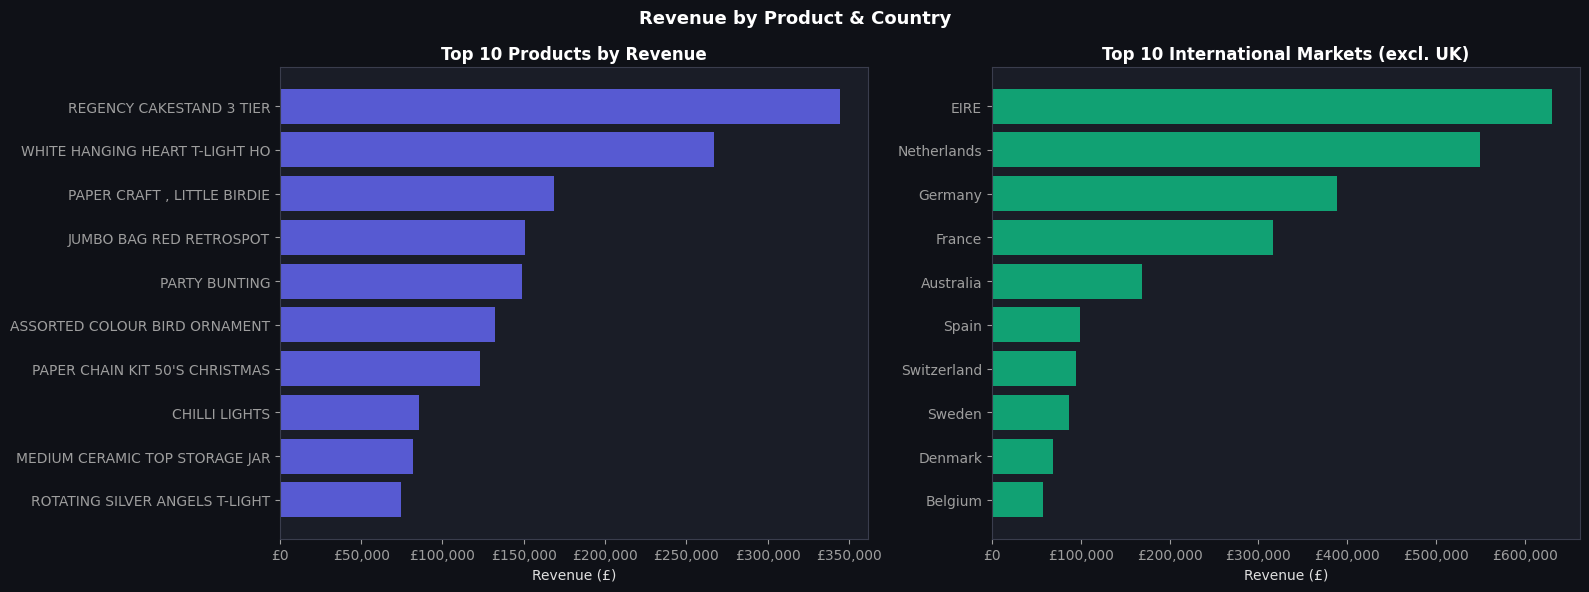

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue by Product & Country',
             fontsize=13, fontweight='bold', color='white')

top_p = df_txn.groupby('description')['revenue'].sum().nlargest(10).sort_values()
ax1.barh(top_p.index.str[:30], top_p.values, color=C_BLUE, alpha=0.85)
ax1.set_title('Top 10 Products by Revenue', fontweight='bold', color='white')
ax1.set_xlabel('Revenue (£)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

top_c = (df_txn[df_txn['country'] != 'United Kingdom']
         .groupby('country')['revenue'].sum().nlargest(10).sort_values())
ax2.barh(top_c.index, top_c.values, color=C_GREEN, alpha=0.85)
ax2.set_title('Top 10 International Markets (excl. UK)',
              fontweight='bold', color='white')
ax2.set_xlabel('Revenue (£)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

plt.tight_layout()
plt.savefig('C:/Users/HP/Downloads/edunet-IBM AIML project/chart_03_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print('Saved:chart_03_top_products.png')

Saved:chart_03_top_products.png


## Correlation Heatmap

Correlation tells us which variables move together.
    
Range: -1 (opposite) → 0 (no link) → +1 (same direction)

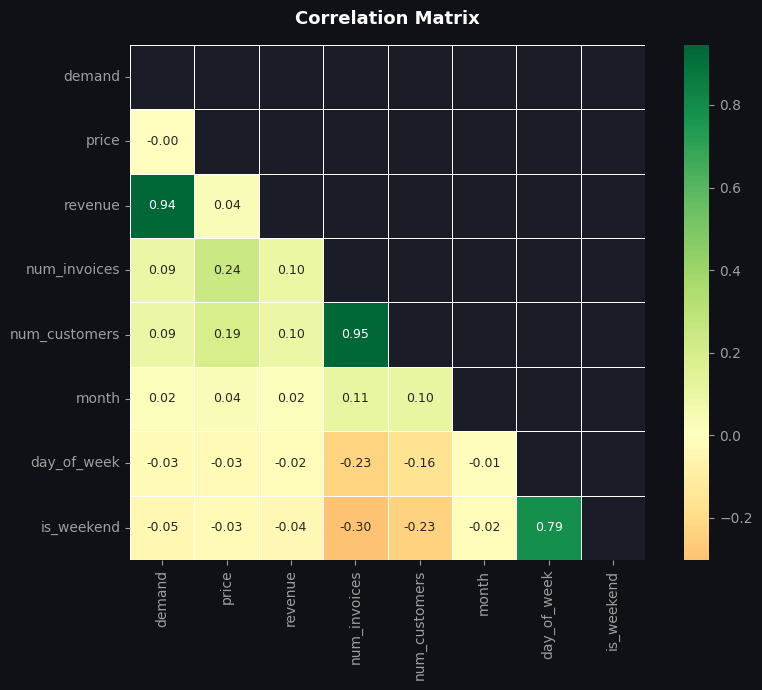

In [14]:
num_cols = [c for c in ['demand','price','revenue','num_invoices',
                         'num_customers','month','day_of_week','is_weekend']
            if c in df.columns]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide duplicate upper triangle

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9}, square=True)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold',
             color='white', pad=15)
plt.tight_layout()
plt.savefig('C:/Users/HP/Downloads/edunet-IBM AIML project/chart_04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print('Saved: chart_04_correlation.png')
print('Green = positive correlation, Red = negative correlation')

Saved: chart_04_correlation.png
Green = positive correlation, Red = negative correlation


## Demand Distribution

We check the SHAPE of our target variable (demand).
    
Heavy skew → consider log transform in feature engineering.
    
Skew > 1.0 means the distribution has a long right tail.

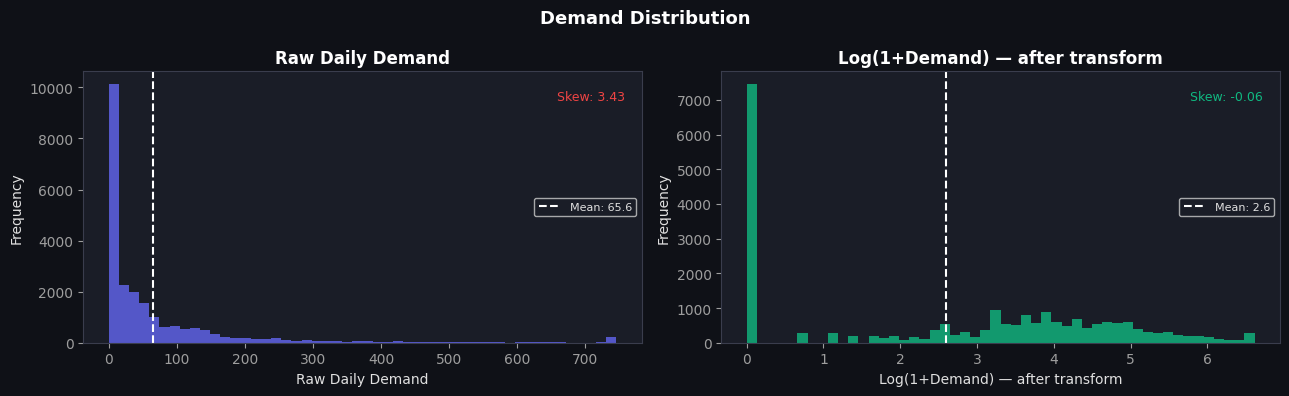

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Demand Distribution', fontsize=13, fontweight='bold', color='white')

for ax, (data, label, color) in zip(axes, [
    (df['demand'], 'Raw Daily Demand', C_BLUE),
    (np.log1p(df['demand']), 'Log(1+Demand) — after transform', C_GREEN),
]):
    data = data.clip(upper=data.quantile(0.99))
    ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(data.mean(), color='white', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.1f}')
    ax.set_title(label, fontweight='bold', color='white')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.text(0.97, 0.93, f'Skew: {data.skew():.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            color=C_RED if abs(data.skew()) > 1 else C_GREEN)

plt.tight_layout()
plt.savefig('C:/Users/HP/Downloads/edunet-IBM AIML project/chart_05_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print('Saved: data/chart_05_distribution.png')
print('Log transform makes distribution more normal → better for linear models')

Saved: data/chart_05_distribution.png
Log transform makes distribution more normal → better for linear models


## EDA Summary

In [18]:
print('\n' + '='*55)
print('EDA SUMMARY')
print('='*55)
print("""
KEY FINDINGS:

1. SEASONALITY
   Q4 (Oct-Dec) drives highest revenue every year.
   November is consistently the peak month.
   → We must encode seasonality into model features.

2. WEEKLY PATTERN
   Thursday and Tuesday are peak days (B2B ordering cycle).
   Sunday has very low sales (this is a B2B retailer).
   → day_of_week and is_weekend are important features.

3. PRODUCT CONCENTRATION
   Top 10 products = ~35% of total revenue.
   Long tail of low-volume products.
   → Focusing on top 50 products is well justified.

4. SKEWED DEMAND DISTRIBUTION
   Raw demand is right-skewed (skew > 1.5).
   Log transform makes it approximately normal.
   → We apply log1p transform in feature engineering.

5. DATA QUALITY
   ~25% of raw rows removed (returns, cancellations).
   Missing Customer IDs kept (anonymous orders are real sales).
   No missing dates or prices after cleaning.
""")


EDA SUMMARY

KEY FINDINGS:

1. SEASONALITY
   Q4 (Oct-Dec) drives highest revenue every year.
   November is consistently the peak month.
   → We must encode seasonality into model features.

2. WEEKLY PATTERN
   Thursday and Tuesday are peak days (B2B ordering cycle).
   Sunday has very low sales (this is a B2B retailer).
   → day_of_week and is_weekend are important features.

3. PRODUCT CONCENTRATION
   Top 10 products = ~35% of total revenue.
   Long tail of low-volume products.
   → Focusing on top 50 products is well justified.

4. SKEWED DEMAND DISTRIBUTION
   Raw demand is right-skewed (skew > 1.5).
   Log transform makes it approximately normal.
   → We apply log1p transform in feature engineering.

5. DATA QUALITY
   ~25% of raw rows removed (returns, cancellations).
   Missing Customer IDs kept (anonymous orders are real sales).
   No missing dates or prices after cleaning.

